In [1]:
import numpy as np
import matplotlib.pyplot as plt

def predictable_feed(trial):
    """A feed with a FIXED reward probability every time."""
    return 1.0 if np.random.rand() < 0.5 else 0.0

def unpredictable_feed(trial):
    """A feed where the reward probability itself randomly drifts —
    you genuinely can't learn a stable expectation."""
    prob = np.random.uniform(0.1, 0.9)  # probability itself is random each trial
    return 1.0 if np.random.rand() < prob else 0.0

What the plots are actually showing you
Top-left (Machine A): the gray line is the real odds (flat, boring, 50%). The green line is what your brain thinks the odds are (V). Notice the green line quickly catches up to the gray line and basically sits right on top of it your brain figured the machine out.
Top-right (Machine B): the gray line (real odds) is wiggling around, going up and down over time. The red line (what your brain thinks) is trying to keep up, but it's always a little late, always chasing because by the time your brain adjusts to "oh it's 80% now," the real odds have already changed again.
Bottom two plots: this is literally the "surprise" (RPE) at each single moment. Machine A's surprise is small and calm occasional small blips, nothing dramatic. Machine B's surprise stays messier and bigger for much longer, because your brain is constantly a little wrong about what's coming.

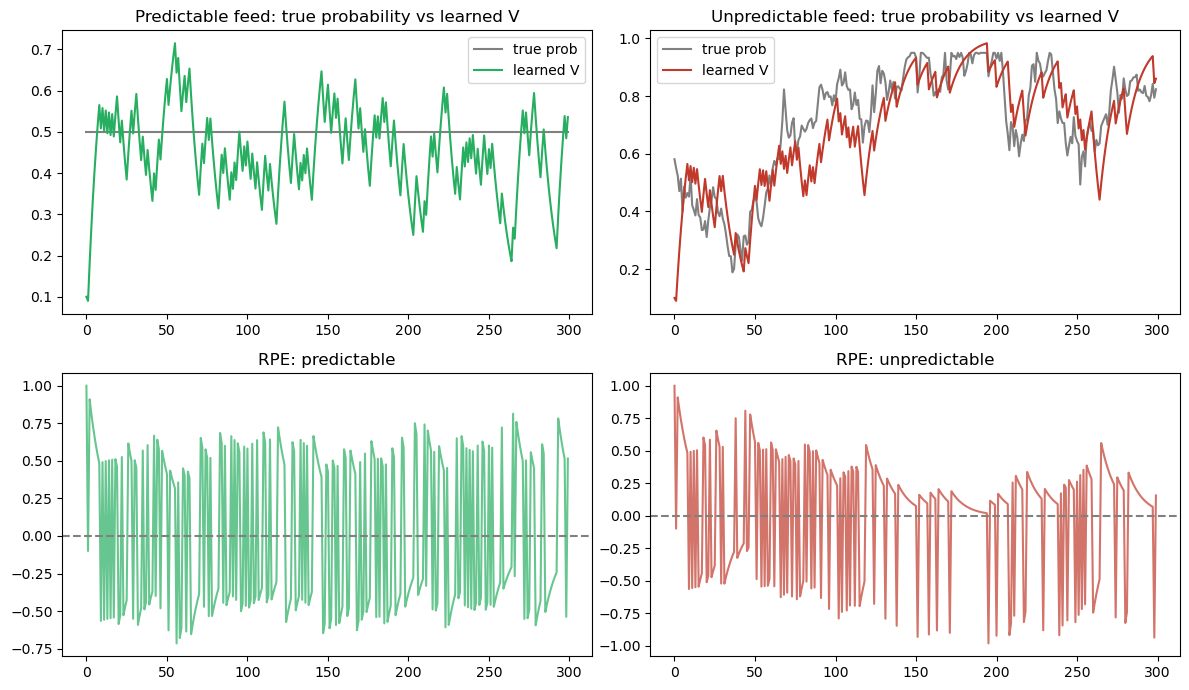

In [3]:
def predictable_feed_prob(n_trials):
    """Fixed reward probability throughout."""
    return np.full(n_trials, 0.5)

def unpredictable_feed_prob(n_trials, seed=1):
    """Reward probability that DRIFTS slowly and randomly over time —
    a moving target the agent can never fully learn."""
    rng = np.random.RandomState(seed)
    probs = np.zeros(n_trials)
    p = 0.5
    for i in range(n_trials):
        p += rng.normal(0, 0.05)   # small random drift each trial
        p = np.clip(p, 0.05, 0.95) # keep it a valid probability
        probs[i] = p
    return probs

def simulate_feed(prob_trace, alpha=0.1, seed=1):
    rng = np.random.RandomState(seed)
    V = 0.0
    n_trials = len(prob_trace)
    RPE_trace = np.zeros(n_trials)
    V_trace = np.zeros(n_trials)

    for trial in range(n_trials):
        R = 1.0 if rng.rand() < prob_trace[trial] else 0.0
        RPE = R - V
        V = V + alpha * RPE
        RPE_trace[trial] = RPE
        V_trace[trial] = V

    return V_trace, RPE_trace

n_trials = 300
pred_probs = predictable_feed_prob(n_trials)
unpred_probs = unpredictable_feed_prob(n_trials)

V_pred, RPE_pred = simulate_feed(pred_probs)
V_unpred, RPE_unpred = simulate_feed(unpred_probs)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes[0,0].plot(pred_probs, color='gray', label='true prob')
axes[0,0].plot(V_pred, color='#27ae60', label='learned V')
axes[0,0].set_title("Predictable feed: true probability vs learned V")
axes[0,0].legend()

axes[0,1].plot(unpred_probs, color='gray', label='true prob')
axes[0,1].plot(V_unpred, color='#c0392b', label='learned V')
axes[0,1].set_title("Unpredictable feed: true probability vs learned V")
axes[0,1].legend()

axes[1,0].plot(RPE_pred, color='#27ae60', alpha=0.7)
axes[1,0].axhline(0, color='gray', linestyle='--')
axes[1,0].set_title("RPE: predictable")

axes[1,1].plot(RPE_unpred, color='#c0392b', alpha=0.7)
axes[1,1].axhline(0, color='gray', linestyle='--')
axes[1,1].set_title("RPE: unpredictable")

plt.tight_layout()
plt.show()

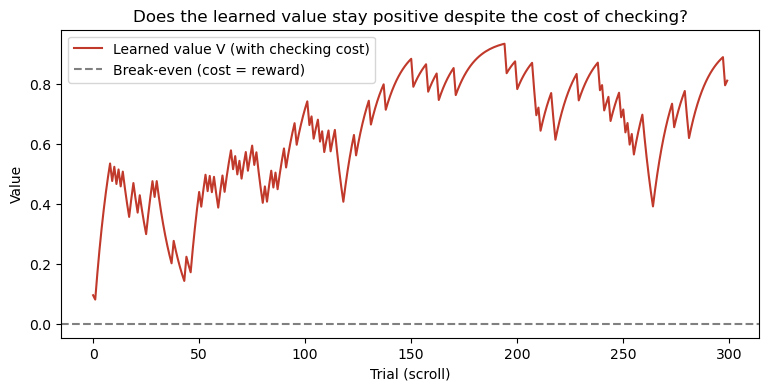

Average learned value: 0.639
Fraction of trials where value was still positive: 100.00%


In [4]:
def simulate_feed_with_cost(prob_trace, alpha=0.1, checking_cost=0.05, seed=1):
    rng = np.random.RandomState(seed)
    V = 0.0
    n_trials = len(prob_trace)
    RPE_trace = np.zeros(n_trials)
    V_trace = np.zeros(n_trials)
    net_value_trace = np.zeros(n_trials)  # reward minus the cost of checking

    for trial in range(n_trials):
        R = 1.0 if rng.rand() < prob_trace[trial] else 0.0
        net_R = R - checking_cost   # the actual felt reward, after paying the "cost" to check
        RPE = net_R - V
        V = V + alpha * RPE
        RPE_trace[trial] = RPE
        V_trace[trial] = V
        net_value_trace[trial] = net_R

    return V_trace, RPE_trace, net_value_trace

V_unpred_cost, RPE_unpred_cost, net_value_trace = simulate_feed_with_cost(unpred_probs)

plt.figure(figsize=(9,4))
plt.plot(V_unpred_cost, color='#c0392b', label='Learned value V (with checking cost)')
plt.axhline(0, color='gray', linestyle='--', label='Break-even (cost = reward)')
plt.xlabel("Trial (scroll)")
plt.ylabel("Value")
plt.title("Does the learned value stay positive despite the cost of checking?")
plt.legend()
plt.show()

print(f"Average learned value: {np.mean(V_unpred_cost):.3f}")
print(f"Fraction of trials where value was still positive: {(V_unpred_cost > 0).mean():.2%}")